In [28]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
from waveNetArchitecture import Value, Linear, BatchNorm1D, Tanh, Embedding, FlattenConsecutive, Sequential, cross_entropy
with open('shakespear.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [29]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

blockSize = 8 # Increase the amount of context
inputs, outputs = [],[]

In [30]:
data = Value(encode(text))
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]
print(data.data[:20])

[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


In [31]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP

# each FlattenConsecutive(2) concatenates 2 neighbours, so the next Linear sees 2x the features
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# last layer: make less confident
model.layers[-1].weight.data *= 0.1
# all other layers: apply gain
for layer in model.layers[:-1]:
    if isinstance(layer, Linear):
        layer.weight.data *= 1.0 #5/3

parameters = model.parameters()
print(sum(p.data.size for p in parameters)) # number of parameters in total

49815


In [42]:
max_steps = 20000
batch_size = 32
lossi = []
ud = []

for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = True # train mode: use batch stats and update the running buffers

# build sliding-window dataset: each input is `blockSize` consecutive tokens,
# target is the next token
tokens = data.data
X, Y = [], []
for j in range(len(tokens) - blockSize):
    X.append(tokens[j : j + blockSize]) # (blockSize,) context indices
    Y.append(tokens[j + blockSize])     # () next-token target
trainInArr = np.array(X)   # (N, blockSize)
trainOutArr = np.array(Y)  # (N,)

for i in range(max_steps):

    # minibatch construct
    ix = np.random.randint(0, trainInArr.shape[0], (batch_size,))
    Xb, Yb = trainInArr[ix], trainOutArr[ix]  # (batch_size, blockSize), (batch_size,)

    # forward pass
    logits = model(Xb)
    loss = cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = np.zeros_like(p.data, dtype=float)
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {float(loss.data):.4f}')
    lossi.append(np.log10(float(loss.data)))
    ud.append([np.log10(np.std(lr * p.grad) / np.std(p.data)) for p in parameters])

    if i >= 1000:
        # break # If you want to.
        pass

      0/  20000: 1.8638
  10000/  20000: 2.0061


C:\Users\28taidan\AppData\Local\Temp\ipykernel_35652\2127502809.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  betterLoss.append(cur/(len(lossi)%SMUSH))


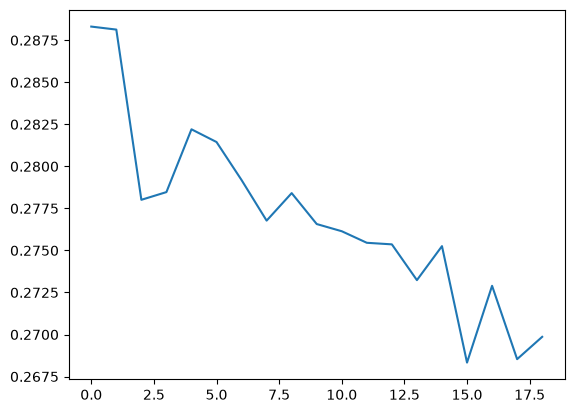

In [44]:
SMUSH = 1000 # resolution of graph. <50 really has too much noise, 1000 is reccomended. Needed bc 32 as a batch size has too much variation.
betterLoss = []
cur = 0
for i in range(len(lossi)):
    cur += lossi[i]
    if i % SMUSH == 0 and i>0:
        betterLoss.append(cur/SMUSH)
        cur = 0
betterLoss.append(cur/(len(lossi)%SMUSH))

plt.plot(betterLoss)

In [49]:
# put batchnorm layers into eval mode so they use the running stats instead of
# per-batch stats (a batch of size 1 has zero variance, which would blow up otherwise)
for layer in model.layers:
    if isinstance(layer, BatchNorm1D):
        layer.training = False

# sample from the model
rng = np.random

for _ in range(20):

    out = []
    context = [26] * blockSize # initialize with the '.' padding token
    while True:
        # forward pass the neural net: feed the (1, blockSize) context of indices
        x = np.array([context]) # (1, blockSize); the Embedding layer looks these up
        logits = model(x)
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        # sample from the distribution
        ix = rng.choice(vocab_size, p=probs[0])
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 26:
            break

    print(''.join(itos[i] for i in out[:-1])) # decode and print the generated word, dropping the trailing '.'

:
Where'd.

MULETTIO:
A all my belt deathslegent were,
And and soul robo;
The death fay smoer, thy conted, if even this wifteds
Fronosh evon,
And him, them, ented vill:?

MOW hold him.

LORTA:
South, to,
Then voing they, as is fuiler, if coupe of for, who will myselvny, Cy wileles he
bread come one hath rath to I tilncers dour tonge bloud; eye! Yuish.

First Cove hongy:
Aire lose.

MUEE
E:
Ais bawn:
As hone,

IO:
Et grather.

ATOUG:

E:
And peatg.

VRIZF:
Cith, ho live elliay, my bese,
Hour and filly till'd care
As
You aw thou, pead your not I, Lownsee,
Of being will.

ISTE
BE:
Cide and king,
In comefate;
But, destars'ETlitonend.

Fich, I caulp the good
That a Pller un day,
Buther that'st.
to pecelenciet, noth light I'll seen herst, and is with my Crown, if with teeper my, him granbe:
And baintersiff his son,
And and countly chould.

CAMIILCUTWIO:
I rous, his with think.
Face site tell they and hell, wheret rear, whenwid hisselble.

PALRIO:

D:
Fo lor.

GRCOLTE:
And Iupbre me toors,
It